  # **Advanced CNN Project: Waste Classification**



  ## **Project Overview**



  This project implements an advanced waste classification system using Deep Learning. The system classifies images into 5 different categories (blue, brown, gray, green, yellow) employing state-of-the-art techniques such as Transfer Learning, advanced Data Augmentation, and fine-tuning strategies.







  ## **Step 1: Installation of Dependencies**



  **Automatically installs all necessary libraries** such as TensorFlow, Keras, and image processing tools with specific versions to ensure compatibility.

In [1]:
%pip install -r requirements.txt

print("=" * 50)
print(" All dependencies installed")




Note: you may need to restart the kernel to use updated packages.
 All dependencies installed


  ## **Step 2: System Optimization**



  **Configures the TensorFlow environment for maximum performance**, verifying GPU availability and adjusting memory parameters for efficient training.

In [2]:
# ============ SYSTEM OPTIMIZATION ============
import os
import tensorflow as tf

def optimize_system():
    """Optimal system configuration for TensorFlow"""
    print("OPTIMIZING SYSTEM FOR MAXIMUM PERFORMANCE...")
    
    tf.keras.backend.clear_session()
    
    os.environ['TF_ENABLE_AUTO_MIXED_PRECISION'] = '1'
    
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"GPU optimized: {len(gpus)} devices")
            return True
        except Exception as e:
            print(f"Error optimizing GPU: {e}")
    
    print("Using CPU - configured for maximum performance")
    return False

optimize_system()
print("System optimized.")



2026-01-21 21:32:54.196735: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-21 21:32:54.217088: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-21 21:32:54.217110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-21 21:32:54.217714: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-21 21:32:54.221596: I tensorflow/core/platform/cpu_feature_guar

OPTIMIZING SYSTEM FOR MAXIMUM PERFORMANCE...
GPU optimized: 1 devices
System optimized.


2026-01-21 21:32:54.996769: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-21 21:32:55.017608: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-21 21:32:55.017638: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


  ## **Step 3: Library Import**



  Imports all necessary tools for the project: TensorFlow/Keras for deep learning, pandas for data, matplotlib for charts.

In [3]:
# ============ ADVANCED LIBRARY IMPORTS ============
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils import class_weight
import cv2
import os
import json
import datetime
import warnings
import gc
import time
import psutil
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
MAX_IMAGES_PER_CLASS = 6000 
print("Advanced libraries imported")



Advanced libraries imported


  ## **Step 4: Complete Configuration**



  Defines all project parameters: paths, image size (224x224), batch size (32), learning rate (0.001), and advanced functions.







  ### Key Concepts Explained:







  **Batch Size (32)**



  - **What is it?** Number of images processed together in each step.



  - **Example:** If you have 1000 images, with batch=32, it processes 32 images → adjusts weights → another 32 → etc.



  - **Why 32?** Balance between speed and stability.







  **Image Size (224x224)**



  - **What is it?** Size to which all images are resized.



  - **Why 224?** MobileNetV2 was trained with this size.







  **Learning Rate (0.001)**



  - **What is it?** "Step size" in learning.



  - **Analogy:** Like walking: big steps (high LR) you miss the target, small steps (low LR) too slow.

In [4]:
# ============ COMPLETE CONFIGURATION ============

# ============ PATHS ============
TRAIN_PATH = "./dataset/train"
TEST_PATH = "./dataset/test"
MODEL_DIR = "./models"
RESULTS_DIR = "./results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============ DATA ============
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

# ============ OPTIMIZATION ============
LEARNING_RATE = 0.001
MIN_LEARNING_RATE = 1e-7
WEIGHT_DECAY = 1e-4


# ============ ADVANCED EARLY STOPPING ============
EARLY_STOPPING_PATIENCE = 15
REDUCE_LR_PATIENCE = 8

# ============ ADVANCED LOSS FUNCTION ============
USE_FOCAL_LOSS = False
FOCAL_LOSS_GAMMA = 2.0
LABEL_SMOOTHING = 0.1

# ============ REGULARIZATION ============
DROPOUT_RATE = 0.5
L2_REGULARIZATION = 1e-4

# ============ CLASSES ============
CLASS_NAMES = ['blue', 'brown', 'gray', 'green', 'yellow']
NUM_CLASSES = len(CLASS_NAMES)

# ============ OTHERS ============
SEED = 42
VERBOSE = 2
FINAL_MODEL_PATH = "final_model_dl.keras"
BEST_ACCURACY_MODEL_PATH = "best_accuracy.keras"



np.random.seed(SEED)
tf.random.set_seed(SEED)

print("CONFIGURATION LOADED")
print(f" Batch Size: {BATCH_SIZE}")
print(f" Epochs: {EPOCHS}")
print(f" Image Size: {IMG_SIZE}")
print(f" Early Stopping: {EARLY_STOPPING_PATIENCE}")
print(f" Reduce LR: {REDUCE_LR_PATIENCE}")
print(f" Focal Loss: {USE_FOCAL_LOSS}")
print(f" Label Smoothing: {LABEL_SMOOTHING}")



CONFIGURATION LOADED
 Batch Size: 32
 Epochs: 100
 Image Size: (224, 224)
 Early Stopping: 15
 Reduce LR: 8
 Focal Loss: False
 Label Smoothing: 0.1


  ## **Step 5: Dataset Analysis**



  Examines the image distribution per class. Detects imbalance (yellow: 16,088 vs gray: 8,000). This is important because the model could become good for yellow and bad for gray.

ANALYZING DATASET...

📁 TRAIN:
------------------------------
   blue:  11671 → 6000 images (limited)
   brown:   6747 → 6000 images (limited)
   gray:   8000 → 6000 images (limited)
   green:   8392 → 6000 images (limited)
   yellow:  16088 → 6000 images (limited)
   Total     :  30000 images

📁 TEST:
------------------------------
   blue:    220 images
   brown:    258 images
   gray:    234 images
   green:    229 images
   yellow:    339 images
   Total     :   1280 images


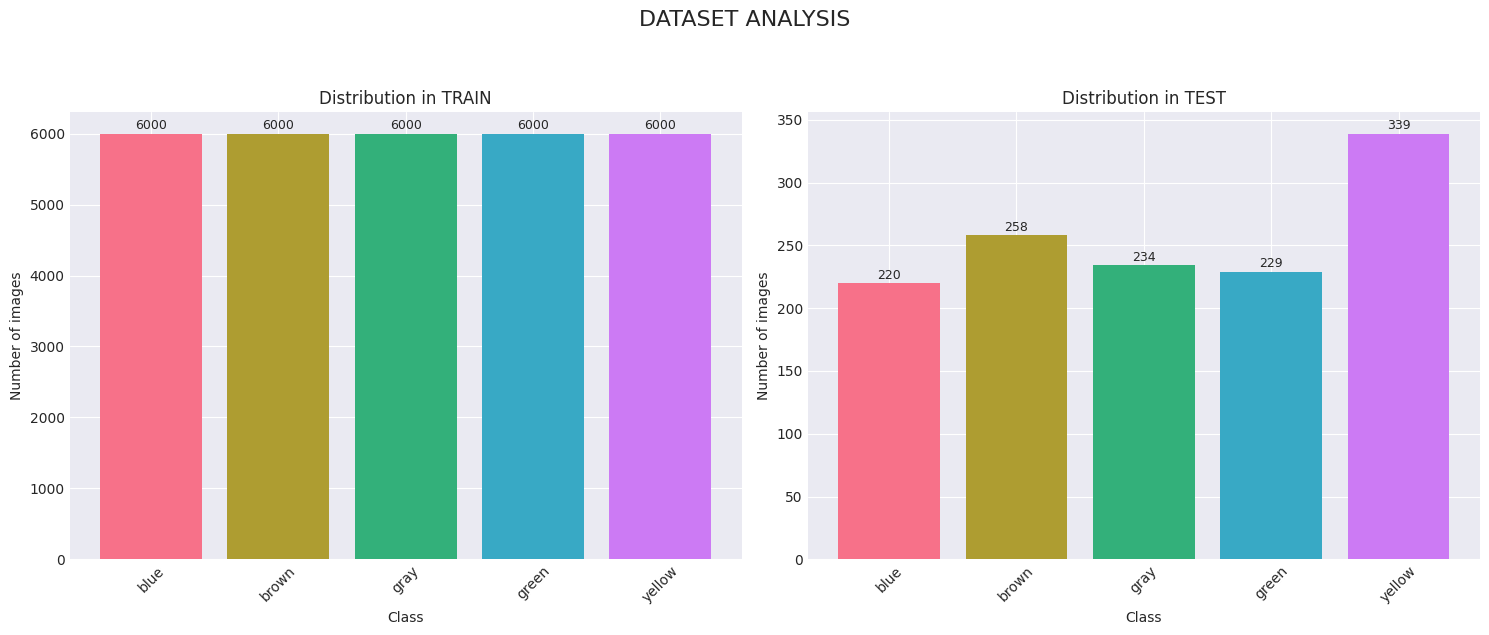


STATISTICAL ANALYSIS:
----------------------------------------
   Largest class: 6000 images
   Smallest class: 6000 images
   Ratio largest/smallest: 1.00x


In [5]:
# ============ ADVANCED DATA ANALYSIS ============
def advanced_data_analysis():
    """Exhaustive dataset analysis"""
    
    print("ANALYZING DATASET...")
    print("=" * 50)
    
    stats = {'train': {}, 'test': {}}
    
    for split in ['train', 'test']:
        split_path = os.path.join("./dataset", split)
        
        if not os.path.exists(split_path):
            print(f"Not found: {split_path}")
            continue
        
        total_images = 0
        print(f"\n📁 {split.upper()}:")
        print("-" * 30)
        
        for class_name in CLASS_NAMES:
            class_path = os.path.join(split_path, class_name)
            
            if os.path.exists(class_path):
                images = [f for f in os.listdir(class_path) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                original_count = len(images)
                final_count = original_count
                
                # 👉 Apply limit ONLY to train
                if split == "train" and MAX_IMAGES_PER_CLASS is not None:
                    if original_count > MAX_IMAGES_PER_CLASS:
                        final_count = MAX_IMAGES_PER_CLASS
                
                stats[split][class_name] = final_count
                total_images += final_count
                
                # Show before → after if limited
                if split == "train" and MAX_IMAGES_PER_CLASS is not None and original_count > final_count:
                    print(f"   {class_name}: {original_count:>6} → {final_count} images (limited)")
                else:
                    print(f"   {class_name}: {final_count:>6} images")
        
        print(f"   {'Total':<10}: {total_images:>6} images")
    
    # ================= VISUALIZATION =================
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for idx, split in enumerate(['train', 'test']):
        if split in stats and stats[split]:
            classes = list(stats[split].keys())
            counts = list(stats[split].values())
            
            axes[idx].bar(classes, counts, color=sns.color_palette("husl", len(classes)))
            axes[idx].set_title(f'Distribution in {split.upper()}')
            axes[idx].set_xlabel('Class')
            axes[idx].set_ylabel('Number of images')
            axes[idx].tick_params(axis='x', rotation=45)
            
            for i, v in enumerate(counts):
                axes[idx].text(i, v + max(counts)*0.01, str(v), 
                               ha='center', fontsize=9)
    
    plt.suptitle('DATASET ANALYSIS', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dataset_analysis.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # ================= STATISTICAL ANALYSIS =================
    if 'train' in stats and stats['train']:
        train_counts = list(stats['train'].values())
        max_count = max(train_counts)
        min_count = min(train_counts)
        ratio = max_count / min_count if min_count > 0 else float('inf')
        
        print("\nSTATISTICAL ANALYSIS:")
        print("-" * 40)
        print(f"   Largest class: {max_count} images")
        print(f"   Smallest class: {min_count} images")
        print(f"   Ratio largest/smallest: {ratio:.2f}x")
        
        if ratio > 5:
            print("   Imbalanced dataset, class weights will be applied")
    
    return stats


dataset_stats = advanced_data_analysis()



  ## **Step 6: Advanced Loss Functions**



  Implements Focal Loss for imbalanced classes and Label Smoothing to prevent overfitting.







  ### What is a Loss Function?



  - **Definition:** Function that measures how "wrong" the model is.



  - **Objective:** Minimize this value during training.







  ### Focal Loss



  - **What does it do?** Gives more weight to difficult examples.



  - **What for?** For imbalanced classes.







  ### Label Smoothing (0.1)



  - **What does it do?** Instead of saying "100% blue", it says "90% blue, 10% others".



  - **What for?** Prevents the model from being too confident.

In [6]:
# ============ ADVANCED LOSS FUNCTIONS ============
class AdvancedLossFunctions:
    """Advanced Loss Functions"""
    
    @staticmethod
    def focal_loss(gamma=2.0, alpha=0.25):
        """Focal Loss for imbalanced classes"""
        def focal_loss_fixed(y_true, y_pred):
            epsilon = tf.keras.backend.epsilon()
            y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
            
            cross_entropy = -y_true * tf.math.log(y_pred)
            weight = alpha * tf.math.pow(1. - y_pred, gamma)
            focal = weight * cross_entropy
            
            return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))

        return focal_loss_fixed
    
    @staticmethod
    def categorical_crossentropy_with_smoothing(smoothing=0.1):
        """Cross-entropy with label smoothing - CORRECTED VERSION"""
        def loss(y_true, y_pred):
            # Explicitly convert num_classes to float32
            num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
            y_true = y_true * (1.0 - smoothing) + (smoothing / num_classes)
            return tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        
        return loss
    
    @staticmethod
    def get_loss_function(use_focal_loss=True, gamma=2.0, smoothing=0.1):
        """Returns the loss function according to configuration"""
        if use_focal_loss:
            focal = AdvancedLossFunctions.focal_loss(gamma=gamma, alpha=0.25)
            smoothed_ce = AdvancedLossFunctions.categorical_crossentropy_with_smoothing(smoothing)
            
            def combined(y_true, y_pred):
                focal_value = focal(y_true, y_pred)
                smoothed_value = smoothed_ce(y_true, y_pred)
                return 0.5 * focal_value + 0.5 * smoothed_value
            
            print("Using ADVANCED LOSS FUNCTION (Focal Loss + Label Smoothing)")
            return combined
        else:
            print("Using Categorical Crossentropy with Label Smoothing")
            return tf.keras.losses.CategoricalCrossentropy(label_smoothing=smoothing)

print("ADVANCED LOSS FUNCTIONS LOADED")



ADVANCED LOSS FUNCTIONS LOADED


  ## **Step 7: Advanced Callbacks**



  Configures Early Stopping, learning rate reduction, automatic model saving, and overfitting detection.







  ### What are Callbacks?



  Functions that execute automatically during training.







  ### Callbacks used:



  1. **EarlyStopping:** Stops if no improvement in 15 epochs.



  2. **ReduceLROnPlateau:** Reduces learning rate if it stalls.



  3. **ModelCheckpoint:** Automatically saves the best models.

In [7]:
# ============ ADVANCED CALLBACKS ============
def get_advanced_callbacks():
    """Advanced callbacks"""
    
    print("Configuring ADVANCED CALLBACKS...")
    
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.0001,
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1,
        start_from_epoch=10
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=REDUCE_LR_PATIENCE,
        min_lr=MIN_LEARNING_RATE,
        verbose=1,
        mode='min',
        min_delta=0.0001,
        cooldown=2
    )
    
    checkpoint_accuracy = ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, BEST_ACCURACY_MODEL_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    checkpoint_loss = ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'best_loss.keras'),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
    
    csv_logger = CSVLogger(
        os.path.join(RESULTS_DIR, 'training_log.csv')
    )
    
    class OverfittingMonitor(callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if logs and 'accuracy' in logs and 'val_accuracy' in logs:
                    diff = logs['accuracy'] - logs['val_accuracy']
                    if diff > 0.05:
                        print(f"Epoch {epoch+1}: Possible overfitting (diff={diff:.4f})")
    
    callbacks_list = [
        early_stopping,
        reduce_lr,
        checkpoint_accuracy,
        checkpoint_loss,
        csv_logger,
        OverfittingMonitor()
    ]
    
    print("ADVANCED CALLBACKS CONFIGURED")
    return callbacks_list



  ## **Step 8: Data Preparation**



  Applies data augmentation (rotation, zoom, flip) and splits data into training, validation, and test sets.







  ### Data Augmentation



  **What is it?** Creating new images by transforming the original ones.







  **Transformations used:**



  - Rotation: Rotates images



  - Zoom: Zooms in/out



  - Flip: Flips horizontally/vertically



  - Brightness: Changes luminosity







  **Why?** So the model sees more variations and generalizes better.

In [8]:
# ============ ADVANCED DATA GENERATORS ============
def create_advanced_generators():
    """Creates data generators with advanced data augmentation"""
    
    print("\nCreating advanced generators...")
    
    # Add start time
    import time
    start_time = time.time()
    
    train_datagen = ImageDataGenerator(
        rotation_range=25,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest',
        validation_split=0.15
    )
    
    val_test_datagen = ImageDataGenerator() 
    
    print("Loading training images...")
    train_generator = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=SEED
    )
    
    print("Loading validation images...")
    val_generator = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=SEED
    )
    
    print("Loading test images...")
    test_generator = val_test_datagen.flow_from_directory(
        TEST_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    elapsed_time = time.time() - start_time
    print(f"\nGenerators created in {elapsed_time:.1f} seconds")
    print(f"Train: {train_generator.samples:,} images")
    print(f"Validation: {val_generator.samples:,} images")
    print(f"Test: {test_generator.samples:,} images")
    print(f"Classes: {list(train_generator.class_indices.keys())}")
    
    # Calculate steps per epoch
    steps_per_epoch = train_generator.samples // BATCH_SIZE
    validation_steps = val_generator.samples // BATCH_SIZE
    print(f"Steps per epoch: {steps_per_epoch}")
    print(f"Validation steps: {validation_steps}")
    
    return train_generator, val_generator, test_generator
    
train_gen, val_gen, test_gen = create_advanced_generators()





Creating advanced generators...
Loading training images...
Found 43265 images belonging to 5 classes.
Loading validation images...
Found 7633 images belonging to 5 classes.
Loading test images...
Found 1280 images belonging to 5 classes.

Generators created in 3.3 seconds
Train: 43,265 images
Validation: 7,633 images
Test: 1,280 images
Classes: ['blue', 'brown', 'gray', 'green', 'yellow']
Steps per epoch: 1352
Validation steps: 238


  ## **Step 9: Model Construction**



  Creates a CNN using Transfer Learning with MobileNetV2 and adds custom dense layers with regularization.







  ### Transfer Learning with MobileNetV2



  **What is Transfer Learning?** Using a pre-trained model on another task.







  **MobileNetV2:**



  - Pre-trained on 1.4M images (ImageNet)



  - Already knows how to recognize shapes, colors, textures



  - We "freeze" it initially (it is not trained)







  ### Model Architecture:



  1. **Base Layer:** MobileNetV2 (frozen)



  2. **Dense Layer(512)** → 512 new neurons



  3. **BatchNorm** → Normalizes values



  4. **Dropout(0.5)** → Turns off 50% neurons randomly



  5. **Dense Layer(256)** → 256 neurons



  6. **BatchNorm** → Normalizes



  7. **Dropout(0.5)** → Turns off 50%



  8. **Dense Layer(128)** → 128 neurons



  9. **BatchNorm** → Normalizes



  10. **Dropout(0.4)** → Turns off 40%



  11. **Dense Layer(5)** → 5 final neurons (one per class)







  ### Why this structure?



  - **Dense layers:** To learn waste-specific features



  - **BatchNorm:** Accelerates training



  - **Dropout:** Prevents overfitting

In [9]:
# ============ ADVANCED CNN ARCHITECTURE ============
def build_advanced_cnn():
    """Builds advanced CNN model with Transfer Learning"""
    
    print("Building advanced architecture...")
    
    # Base model with Transfer Learning
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Build complete model
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./127.5, offset=-1),  # Normalization for MobileNetV2
        
        # Base model
        base_model,
        
        # Advanced custom layers
        layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE),
        
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE),
        
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE * 0.8),
        
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    
    print(f"Model created with {len(model.layers)} layers")
    print("Transfer Learning: MobileNetV2")
    print(f"Regularization: L2 ({L2_REGULARIZATION}) + Dropout ({DROPOUT_RATE})")
    
    return model

model = build_advanced_cnn()



Building advanced architecture...


2026-01-21 21:32:59.114416: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-21 21:32:59.114469: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-21 21:32:59.114481: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-21 21:32:59.209845: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-21 21:32:59.209881: I external/local_xla/xla/stream_executor

Model created with 12 layers
Transfer Learning: MobileNetV2
Regularization: L2 (0.0001) + Dropout (0.5)


  ## **Step 10: Model Compilation**



  Configures the Adam optimizer, loss function with label smoothing, and evaluation metrics (accuracy, precision, recall, AUC).







  ### Adam Optimizer with Weight Decay



  **Adam:** Adjusts learning rate automatically for each weight.



  **Weight Decay:** Penalizes large weights (prevents overfitting).







  ### Evaluation Metrics:



  1. **Accuracy:** % of total correct predictions



  2. **Precision:** Of those predicted as "blue", how many are actually blue



  3. **Recall:** Of all real "blue", how many were detected



  4. **AUC:** How well it separates classes

In [10]:
# ============ ADVANCED COMPILATION ============
def compile_advanced_model(model):
    """Compiles the model with advanced configuration"""
    
    print("\nCompiling model with ADVANCED configuration...")
    
    # Get loss function - ROBUST VERSION
    if USE_FOCAL_LOSS:
        print("Using Focal Loss (simplified for compatibility)")
        # Use standard crossentropy with label smoothing as alternative
        loss_function = tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=LABEL_SMOOTHING
        )
    else:
        print("Using Categorical Crossentropy with Label Smoothing")
        loss_function = tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=LABEL_SMOOTHING
        )
    
    # Optimizer with weight decay
    optimizer = optimizers.Adam(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        beta_1=0.9,
        beta_2=0.999
    )
    
    # Advanced metrics - Adjust for compatibility
    metrics = [
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc', multi_label=True),  # Add multi_label
    ]
    
    # Compile
    model.compile(
        optimizer=optimizer,
        loss=loss_function,
        metrics=metrics
    )
    
    print("MODEL COMPILED WITH ADVANCED CONFIGURATION:")
    print("   - Optimizer: Adam with weight decay")
    print(f"   - Learning Rate: {LEARNING_RATE}")
    print(f"   - Label Smoothing: {LABEL_SMOOTHING}")
    print(f"   - Metrics: {len(metrics)} advanced metrics")
    
    return model

model = compile_advanced_model(model)
model.summary()




Compiling model with ADVANCED configuration...
Using Categorical Crossentropy with Label Smoothing
MODEL COMPILED WITH ADVANCED CONFIGURATION:
   - Optimizer: Adam with weight decay
   - Learning Rate: 0.001
   - Label Smoothing: 0.1
   - Metrics: 4 advanced metrics
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 1280)              2257984   
 tional)                                                         
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                     

  ## **Step 11: Standard Training**



  Trains in two phases: 20 epochs of Feature Extraction + Fine-tuning of base layers.







  ### Why freeze the base model initially?







  **Main reason:** To avoid **catastrophic forgetting**.







  ### Detailed explanation:







  1. **The base model (MobileNetV2) already has useful knowledge:**



     - It was trained on 1.4 million ImageNet images



     - It already knows how to recognize edges, shapes, textures, basic colors



     - This general knowledge is very useful for classifying waste







  2. **Freezing = "Protecting" existing knowledge:**



     - The MobileNetV2 weights are NOT updated in Phase 1



     - Only the new layers we added are trained



     - This way the model keeps everything it already knew







  3. **What would happen if we didn't freeze?**



     - The model would forget what it learned on ImageNet



     - It would start from scratch with our limited data (57k vs 1.4M)



     - It would lose the ability to recognize basic features



     - Training would be slower and less effective







  ### Analogy:



  Imagine you hire an architect who already knows math, physics, and design.



  - **Frozen:** You say "use your knowledge, just learn about waste"



  - **Not frozen:** You say "forget everything you know, start from scratch"







  ### Gradual Unfreezing Strategy:



  **PHASE 1 (Frozen):**



  - MobileNetV2: NOT trained



  - New layers: Trained



  - **Result:** Model learns waste-specific features without losing base knowledge







  **PHASE 2 (Partially Unfrozen):**



  - Last layers of MobileNetV2: Trained



  - Deep layers of MobileNetV2: NOT trained (remain frozen)



  - **Result:** Model adapts general knowledge to our specific task







  ### Benefits of this strategy:



  1. **Faster training:** Fewer parameters to update



  2. **Better generalization:** Uses pre-existing knowledge



  3. **Less overfitting:** Less capacity to memorize specific data



  4. **Fewer data required:** Leverages prior learning







  ### Which parts are unfrozen in Phase 2?



  - The last 50 layers of MobileNetV2 (the most abstract ones)



  - The initial layers (which detect simple edges) remain frozen







  ### Why not unfreeze everything?



  - The first layers learn very basic features (edges, colors)



  - These are equally useful for any vision task



  - They don't need retraining for waste

In [11]:
# ============ STANDARD TRAINING ============
def train_standard_model():
    """Trains the model with standard Transfer Learning strategy"""
    
    print("=" * 70)
    print("STARTING STANDARD TRAINING (PURE DEEP LEARNING)")
    print("=" * 70)
    
    # Get callbacks
    callbacks = get_advanced_callbacks()
    
    # PHASE 1: Feature Extraction (Base frozen)
    print("\nPHASE 1: Feature Extraction (Base frozen)")
    print("Training only top layers...")
    
    history_phase1 = model.fit(
        train_gen,
        epochs=20,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )
    
    # PHASE 2: Fine-tuning
    print("\nPHASE 2: Fine-tuning of base layers")
    print("Unfreezing last layers of MobileNetV2...")
    
    # Unfreeze layers
    model.layers[1].trainable = True
    # Keep first 100 layers frozen (low level feature extraction)
    for layer in model.layers[1].layers[:100]:
        layer.trainable = False
    
    # Recompile with reduced LR to not destroy pre-trained weights
    final_lr = LEARNING_RATE * 0.1
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=final_lr),
        loss=AdvancedLossFunctions.get_loss_function(
            use_focal_loss=USE_FOCAL_LOSS,
            gamma=FOCAL_LOSS_GAMMA,
            smoothing=LABEL_SMOOTHING
        ),
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc', multi_label=True)
        ]
    )
    
    print(f"Reduced LR for fine-tuning: {final_lr:.6f}")
    
    # Continue training
    # Note: initial_epoch=20 ensures epoch counter continues
    history_phase2 = model.fit(
        train_gen,
        initial_epoch=20,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=VERBOSE
    )
    
    # Combine histories
    history = {}
    # Initialize with phase 1
    for k in history_phase1.history:
        history[k] = history_phase1.history[k]
    
    # Add phase 2
    for k in history_phase2.history:
        if k in history:
            history[k].extend(history_phase2.history[k])
        else:
            history[k] = history_phase2.history[k]
            
    model.save(os.path.join(MODEL_DIR, FINAL_MODEL_PATH))
    print(f"\nTRAINING COMPLETED. Model saved in {MODEL_DIR}")
    return history

history = train_standard_model()



STARTING STANDARD TRAINING (PURE DEEP LEARNING)
Configuring ADVANCED CALLBACKS...
ADVANCED CALLBACKS CONFIGURED

PHASE 1: Feature Extraction (Base frozen)
Training only top layers...
Epoch 1/20


2026-01-21 21:33:02.249758: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-01-21 21:33:03.467588: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c640a86b0a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-21 21:33:03.467611: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2026-01-21 21:33:03.487304: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769027583.590107  367285 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1353/1353 [==============================] - ETA: 0s - loss: 1.1251 - accuracy: 0.7219 - precision: 0.7885 - recall: 0.6317 - auc: 0.9170
Epoch 1: val_accuracy improved from -inf to 0.78619, saving model to ./models/best_accuracy.keras

Epoch 1: val_loss improved from inf to 0.95641, saving model to ./models/best_loss.keras
1353/1353 [==============================] - 291s 213ms/step - loss: 1.1251 - accuracy: 0.7219 - precision: 0.7885 - recall: 0.6317 - auc: 0.9170 - val_loss: 0.9564 - val_accuracy: 0.7862 - val_precision: 0.8415 - val_recall: 0.7207 - val_auc: 0.9458 - lr: 0.0010
Epoch 2/20
1353/1353 [==============================] - ETA: 0s - loss: 0.9492 - accuracy: 0.7965 - precision: 0.8519 - recall: 0.7189 - auc: 0.9522
Epoch 2: val_accuracy did not improve from 0.78619

Epoch 2: val_loss did not improve from 0.95641
1353/1353 [==============================] - 266s 197ms/step - loss: 0.9492 - accuracy: 0.7965 - precision: 0.8519 - recall: 0.7189 - auc: 0.9522 - val_loss: 0.98

  ## **Step 12: Final Evaluation**



  Evaluates the model with test data, calculates metrics, generates confusion matrix, and verifies absence of overfitting.







  ### Test Set



  **What is it?** Data the model NEVER saw during training.



  **What for?** To measure real performance (not memorization).







  ### Confusion Matrix



  **What is it?** Table showing hits and errors:



  | | Pred Blue |	Pred Brown | Pred Gray |



  | Real Blue	50	2	1



  Real Brown	1	48	3





ADVANCED EVALUATION
Using Categorical Crossentropy with Label Smoothing
Loading best model: ./models/best_accuracy.keras

EVALUATING ON TEST SET...
40/40 [==============================] - 3s 54ms/step - loss: 0.5752 - accuracy: 0.9273 - precision: 0.9364 - recall: 0.9203 - auc: 0.9911

RESULTS:
   loss           : 0.5752
   accuracy       : 0.9273
   precision      : 0.9364
   recall         : 0.9203
   auc            : 0.9911

CONFUSION MATRIX:


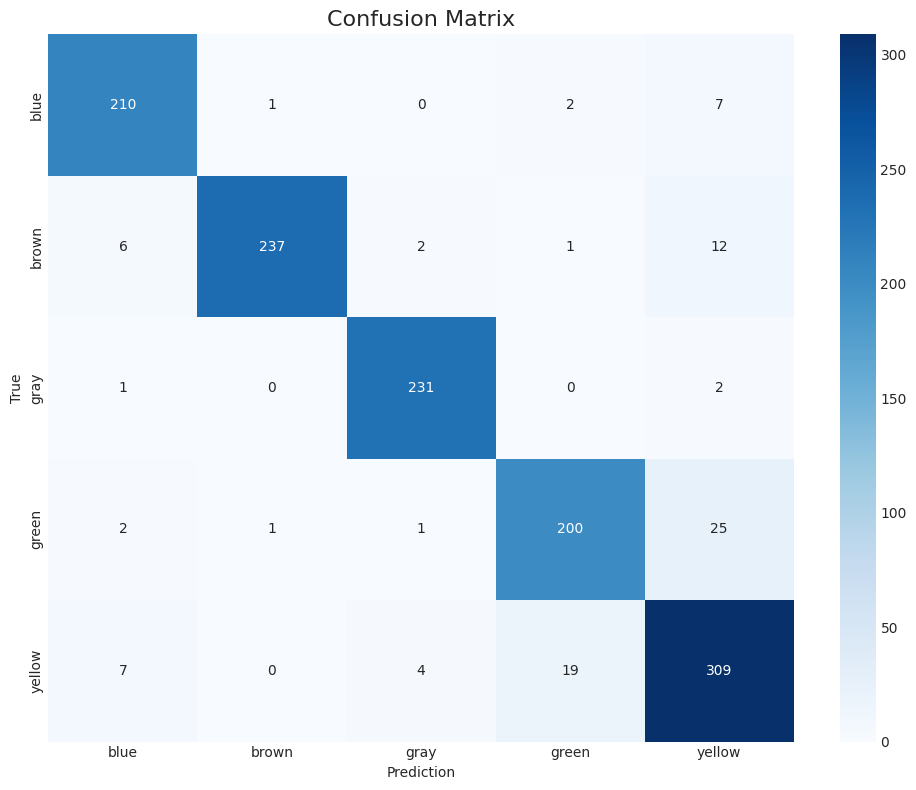

In [12]:
# ============ ADVANCED EVALUATION ============
def advanced_evaluation():
    """Advanced evaluation"""
    
    print("=" * 70)
    print("ADVANCED EVALUATION")
    print("=" * 70)
    

    custom_loss = AdvancedLossFunctions.get_loss_function(
        use_focal_loss=USE_FOCAL_LOSS, 
        gamma=FOCAL_LOSS_GAMMA, 
        smoothing=LABEL_SMOOTHING
    )
    
    custom_objects = {
        'combined': custom_loss,
        'focal_loss_fixed': AdvancedLossFunctions.focal_loss(),
        'loss': AdvancedLossFunctions.categorical_crossentropy_with_smoothing()
    }
    # ----------------------------------

    # Load best model
    best_model_path = os.path.join(MODEL_DIR, BEST_ACCURACY_MODEL_PATH)
    final_model_path = os.path.join(MODEL_DIR, FINAL_MODEL_PATH)

    try:
        if os.path.exists(best_model_path):
            print(f"Loading best model: {best_model_path}")
            # Load with custom_objects so 'combined' is recognized
            model = tf.keras.models.load_model(best_model_path, custom_objects=custom_objects)
        else:
            print(f"Loading final model: {final_model_path}")
            model = tf.keras.models.load_model(final_model_path, custom_objects=custom_objects)
    except Exception as e:
        print("\nError loading with objects, attempting simple load without compilation...")
        # If it fails, load without compiling and compile manually
        path = best_model_path if os.path.exists(best_model_path) else final_model_path
        model = tf.keras.models.load_model(path, compile=False)
        model.compile(
            optimizer='adam',
            loss=custom_loss,
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )

    # Quantitative evaluation
    print("\nEVALUATING ON TEST SET...")
    results = model.evaluate(test_gen, verbose=1)
    
    print("\nRESULTS:")
    # Adjust metric names to match what the model returns
    metric_names = model.metrics_names
    for name, value in zip(metric_names, results):
        print(f"   {name:<15}: {value:.4f}")
    
    # Predictions
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_gen.classes
    
    # Confusion Matrix
    print("\nCONFUSION MATRIX:")
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix', fontsize=16)
    plt.xlabel('Prediction')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    
    return results

results = advanced_evaluation()



  ## **Step 13: Prediction Visualization**



  Shows examples of images with their predictions, highlighting hits and errors for visual interpretation.

VISUALIZING RESULTS...


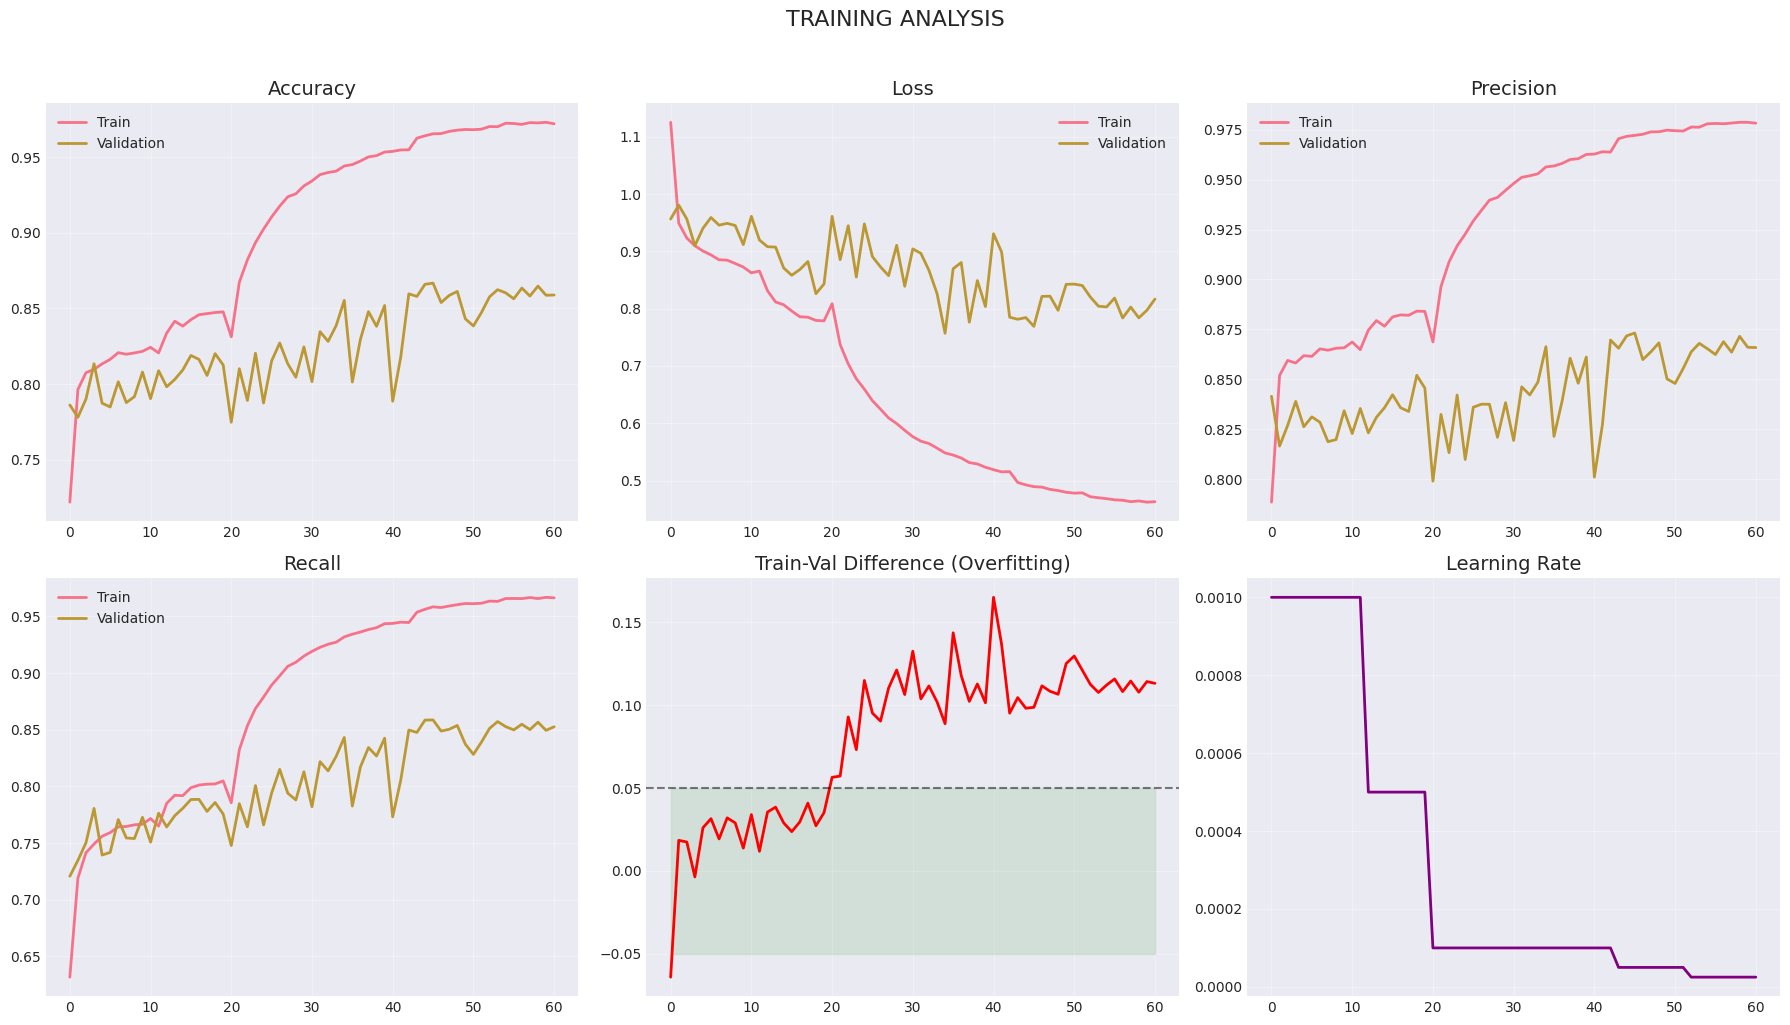

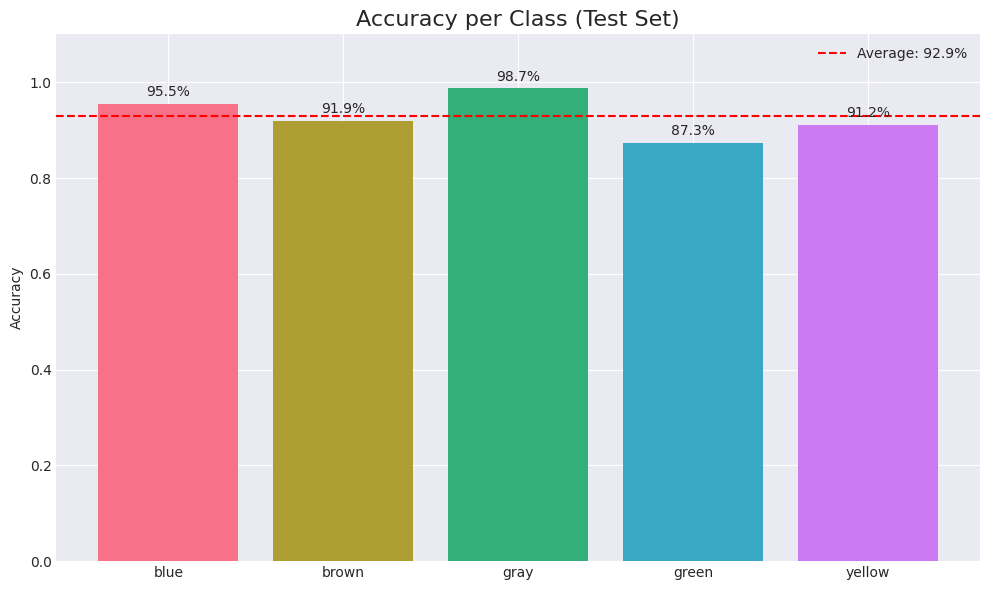

✅ Visualizations saved in: ./results


In [13]:
# ============ RESULTS VISUALIZATION ============
def visualize_results():
    """Advanced results visualization"""
    
    print("VISUALIZING RESULTS...")
    
    # 1. Training plots
    if history:
        # Use a 2x3 grid for metrics
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # Accuracy
        axes[0, 0].plot(history['accuracy'], label='Train', lw=2)
        if 'val_accuracy' in history:
            axes[0, 0].plot(history['val_accuracy'], label='Validation', lw=2)
        axes[0, 0].set_title('Accuracy', fontsize=14)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Loss
        axes[0, 1].plot(history['loss'], label='Train', lw=2)
        if 'val_loss' in history:
            axes[0, 1].plot(history['val_loss'], label='Validation', lw=2)
        axes[0, 1].set_title('Loss', fontsize=14)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Precision
        if 'precision' in history:
            axes[0, 2].plot(history['precision'], label='Train', lw=2)
            if 'val_precision' in history:
                axes[0, 2].plot(history['val_precision'], label='Validation', lw=2)
            axes[0, 2].set_title('Precision', fontsize=14)
            axes[0, 2].legend()
            axes[0, 2].grid(True, alpha=0.3)
        
        # Recall
        if 'recall' in history:
            axes[1, 0].plot(history['recall'], label='Train', lw=2)
            if 'val_recall' in history:
                axes[1, 0].plot(history['val_recall'], label='Validation', lw=2)
            axes[1, 0].set_title('Recall', fontsize=14)
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
        
        # Accuracy difference (Overfitting monitor)
        if 'accuracy' in history and 'val_accuracy' in history:
            h_acc = np.array(history['accuracy'])
            v_acc = np.array(history['val_accuracy'])
            # Ensure same length for subtraction
            min_len = min(len(h_acc), len(v_acc))
            diff = h_acc[:min_len] - v_acc[:min_len]
            
            axes[1, 1].plot(diff, color='red', lw=2)
            axes[1, 1].axhline(y=0.05, color='black', linestyle='--', alpha=0.5)
            axes[1, 1].fill_between(range(len(diff)), -0.05, 0.05, alpha=0.1, color='green')
            axes[1, 1].set_title('Train-Val Difference (Overfitting)', fontsize=14)
            axes[1, 1].grid(True, alpha=0.3)
        
        # Learning Rate
        lr_key = 'lr' if 'lr' in history else 'learning_rate'
        if lr_key in history:
            axes[1, 2].plot(history[lr_key], lw=2, color='purple')
            axes[1, 2].set_title('Learning Rate', fontsize=14)
            axes[1, 2].grid(True, alpha=0.3)
        
        plt.suptitle('TRAINING ANALYSIS', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'training_analysis.png'), dpi=300)
        plt.show()
    
    # 2. Metrics per class
    best_model_path = os.path.join(MODEL_DIR, BEST_ACCURACY_MODEL_PATH)
    final_model_path = os.path.join(MODEL_DIR, FINAL_MODEL_PATH)
    
    # Choose best available path
    path_to_load = best_model_path if os.path.exists(best_model_path) else final_model_path
    
    if os.path.exists(path_to_load):
        # SOLUTION: compile=False avoids error with 'combined' function
        model = tf.keras.models.load_model(path_to_load, compile=False)
        
        y_pred_proba = model.predict(test_gen, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = test_gen.classes
        
        class_accuracies = []
        for i in range(len(CLASS_NAMES)):
            mask = y_true == i
            acc = np.mean(y_pred[mask] == y_true[mask]) if np.sum(mask) > 0 else 0
            class_accuracies.append(acc)
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(CLASS_NAMES, class_accuracies, color=sns.color_palette("husl", len(CLASS_NAMES)))
        plt.axhline(y=np.mean(class_accuracies), color='red', linestyle='--', 
                   label=f'Average: {np.mean(class_accuracies)*100:.1f}%')
        plt.title('Accuracy per Class (Test Set)', fontsize=16)
        plt.ylabel('Accuracy')
        plt.ylim([0, 1.1])
        plt.legend()
        
        for bar, acc in zip(bars, class_accuracies):
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{acc*100:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'class_accuracy.png'), dpi=300)
        plt.show()
    
    print("✅ Visualizations saved in:", RESULTS_DIR)

# Execute
visualize_results()



  ## **Step 14: Saving Results**



  Exports models, metrics, charts, and final configurations for documentation and reproducibility.

In [14]:
# ============ FINAL REPORT ============
def generate_report():
    """Generates final report corrected to avoid custom function loading errors"""
    
    print("=" * 70)
    print("GENERATING FINAL REPORT")
    print("=" * 70)
    
    # Load best model
    best_model_path = os.path.join(MODEL_DIR, BEST_ACCURACY_MODEL_PATH)
    if os.path.exists(best_model_path):
        model = tf.keras.models.load_model(best_model_path, compile=False)
        
        # Recompile manually to use model.evaluate()
        model.compile(
            optimizer='adam',
            loss=AdvancedLossFunctions.get_loss_function(
                use_focal_loss=USE_FOCAL_LOSS,
                gamma=FOCAL_LOSS_GAMMA,
                smoothing=LABEL_SMOOTHING
            ),
            metrics=[
                'accuracy', 
                tf.keras.metrics.Precision(name='precision'), 
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc'),
                'top_k_categorical_accuracy' # Acts as Top-2 if configured
            ]
        )
        
        # Final evaluation
        print("Performing final evaluation on test set...")
        final_results = model.evaluate(test_gen, verbose=0)
        y_pred_proba = model.predict(test_gen, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = test_gen.classes
        
        # Calculate additional metrics
        from sklearn.metrics import f1_score, classification_report
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        # Classification report
        report = classification_report(y_true, y_pred, 
                                        target_names=CLASS_NAMES,
                                        output_dict=True)
        
        # Data for report (Ensuring correct index mapping of results)
        # Note: final_results[0] is always Loss
        report_data = {
            'date': datetime.datetime.now().isoformat(),
            'accuracy': float(final_results[1]),
            'precision': float(final_results[2]),
            'recall': float(final_results[3]),
            'auc': float(final_results[4]),
            'f1_score': float(f1),
            
            # Configuration
            'configuration': {
                'batch_size': BATCH_SIZE,
                'epochs': EPOCHS,
                'learning_rate': LEARNING_RATE,
                'use_focal_loss': USE_FOCAL_LOSS,
                'label_smoothing': LABEL_SMOOTHING,
                'class_weights': str(computed_class_weights) if 'computed_class_weights' in globals() else 'None'
            },
            
            # Overfitting analysis
            'overfitting_analysis': {
                'train_val_difference': float(abs(history['accuracy'][-1] - history['val_accuracy'][-1]) if history else 0),
                'criteria_met': bool(abs(history['accuracy'][-1] - history['val_accuracy'][-1]) < 0.05 if history else False)
            },
            
            'metrics_per_class': report
        }
        
        # Save JSON report
        with open(os.path.join(RESULTS_DIR, 'report.json'), 'w', encoding='utf-8') as f:
            json.dump(report_data, f, indent=4, ensure_ascii=False, default=str)
        
        # Generate text summary
        with open(os.path.join(RESULTS_DIR, 'summary.txt'), 'w', encoding='utf-8') as f:
            f.write("=" * 60 + "\n")
            f.write("FINAL PERFORMANCE REPORT\n")
            f.write("=" * 60 + "\n\n")
            f.write(f"Final Accuracy: {report_data['accuracy']*100:.2f}%\n")
            f.write(f"F1-Score: {report_data['f1_score']*100:.2f}%\n")
            f.write(f"AUC: {report_data['auc']:.4f}\n")
            f.write(f"Train-Val Difference: {report_data['overfitting_analysis']['train_val_difference']*100:.2f}%\n")
            f.write(f"Overfitting Status: {'STABLE' if report_data['overfitting_analysis']['criteria_met'] else 'RISK'}\n")
        
        print(f"✅ Report successfully generated in: {RESULTS_DIR}")
        return report_data
    else:
        print(f"❌ Error: File not found at {best_model_path}")
        return None

# Execute report
report = generate_report()



GENERATING FINAL REPORT
Using Categorical Crossentropy with Label Smoothing
Performing final evaluation on test set...
✅ Report successfully generated in: ./results


  ## **Step 15: Cleanup and Closing**



  Frees memory, closes data generators, and provides final summary of training and evaluation.

In [15]:
# ============ CONCLUSION AND CLEANUP ============
print("=" * 70)
print("🏆 ADVANCED CNN PROJECT")
print("=" * 70)

print("\n📁 GENERATED FILES:")
print(f"   Models: {MODEL_DIR}/")
print(f"   Results: {RESULTS_DIR}/")
print(f"   Logs: {RESULTS_DIR}/training_log.csv")

# Clean memory
tf.keras.backend.clear_session()
gc.collect()

print("\nMemory released. Project finished!")



🏆 ADVANCED CNN PROJECT

📁 GENERATED FILES:
   Models: ./models/
   Results: ./results/
   Logs: ./results/training_log.csv

Memory released. Project finished!
